## Middleware

Middleware provides a way to more tightly control what happens inside the agent. Middleware is useful for the following:

- Tracking agent behaviour with logging, analytics, and debugging
- Transforming prompts, tool selection, and output formatting
- Adding retries, fallbacks, and early termination logic.
- Applying rate limits, guardrails, and PII detection

In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()


True

### Summarization Middleware

Automatically summarize conversation history when approaching token limits, preserving recent messages while compressing older context. Summarization is useful for the following:

- Long running conversations that exceed context windows.
- Multi-turn dialogues with extensive history
- Applications where preserving full conversation context matters.

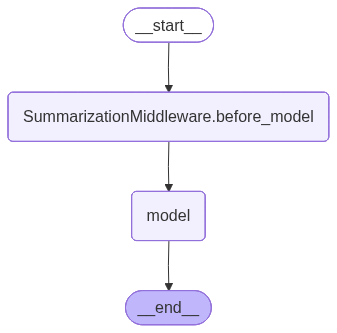

In [2]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage

model = ChatOpenAI(
    model = "nvidia/nemotron-3-super-120b-a12b:free",
    api_key = os.environ["OPENROUTER_API_KEY"],
    base_url = "https://openrouter.ai/api/v1"
)

agent = create_agent(
    model = model,
    tools = [],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = model,
            trigger = ("messages",10),
            keep=("messages",4)
        )
    ]
)
agent

### Note:

A normal Langchain agent has no memory across multiple conversation turns therefore we need to use a checkpointer to store the context in a thread. 

A Thread is like a container to store context of the conversations which the agent is then going to use to maintain context over multiple conversation turns

In [3]:
### Run with thread id
config = {"configurable" : {"thread_id" : "test-1"}}

In [4]:
# Alternative test data
questions = [
    "What is 2+2?",
    "what is 10*5?",
    "What is 100/4?",
    "what is 15-7 ?",
    "what is 3*3 ?",
    "What is 4*4 ?"
]

for q in questions:
    response = agent.invoke({"messages" : [HumanMessage(content = q)]}, config)
    print(f"messages : {response}")
    print(f"Messages: {len(response['messages'])}")

messages : {'messages': [HumanMessage(content='What is 2+2?', additional_kwargs={}, response_metadata={}, id='6beee0a1-9e79-46ec-b890-62d0e8f78bf3'), AIMessage(content='4', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 47, 'prompt_tokens': 23, 'total_tokens': 70, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 43, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-super-120b-a12b-20230311:free', 'system_fingerprint': None, 'id': 'gen-1782882107-LsyF37FruYRcEnPpKiU8', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019f1c0e-0043-72e3-b863-ab360345512

In [6]:
print(response['messages'][-1].content)

16  

*Explanation:*  
4 multiplied by 4 equals 16, because 4 + 4 + 4 + 4 = 16 (or 4 × 4 = 16).  

You're on a roll! 😄 Ready for another? Just ask.


In [5]:
state = agent.get_state(config)
print(len(state.values["messages"]))

6


In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool

model = ChatOpenAI(
    model = "nvidia/nemotron-3-super-120b-a12b:free",
    api_key = os.environ["OPENROUTER_API_KEY"],
    base_url = "https://openrouter.ai/api/v1"
)
@tool
def search_hotels(city:str) -> str:
    """Search hotels : returns long response to use more tokens."""
    return f""" Hotels in {city}:
    1. Grand Hotel - 5 star, ₹350/night, spa, pool, gym
    2. City Inn - 4 star, ₹100/night, business center
    3. Budget Stay - 3 star, ₹75/night, free wifi
"""

agent = create_agent(
    model = model,
    tools = [search_hotels],
    checkpointer=InMemorySaver(),
    middleware=[
        SummarizationMiddleware(
            model = model,
            trigger = ("tokens",550),
            keep=("tokens",200)
        )
    ]
)

agent
config = {"configurable" : {"thread_id" : "test_1"}}

##Token counter(approximate)

def count_tokens(messages):
    total_chars = sum(len(str(m.content)) for m in messages)
    return total_chars // 4 # 4 chars = 1 token